In [1]:
from operator import concat
from timeit import timeit

import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt

In [5]:
input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
# input["star_name"][0] = "012345678901234567890123456789"
name_list = input["star_name"]
name_list.pprint()

       star_name       
-----------------------
          TIC 459832522
          TIC 245873777
          TIC 272314138
          TIC 322899250
          TIC 368326352
          TIC 471011144
          TIC 280310048
          TIC 471011145
          TIC 157587146
          TIC 423088367
                    ...
            Wolf 1201 B
               G 156-36
                G 275-2
            BD-20 6558B
               G 242-44
               G 242-45
2MASS J16334908-6808480
2MASS J16334976-6808488
            Wolf 1561 A
            Wolf 1561 B
Length = 14571 rows


In [6]:
input["sy_dist"].max()

np.float64(49.99839401245117)

In [9]:
sim = Simbad
# sim.remove_votable_fields("*")
sim.reset_votable_fields()
sim.add_votable_fields("ids")
# sim.list_votable_fields().pprint_all()
# sim.query_criteria("dist")
sim.query_objectids()

In [10]:
# note if all 14571 stars have ~60 alternate id's that needs handling and searching of a total of ids on the order of, which is very slow
59*14571

859689

In [33]:
alternate_ids = sim.query_objectids(name_list[2], get_query_payload=True)
alternate_ids

{'REQUEST': 'doQuery',
 'LANG': 'ADQL',
 'MAXREC': 10000,
 'QUERY': "SELECT ident.id FROM ident AS id_typed JOIN ident USING(oidref)WHERE id_typed.id = 'TIC 272314138'"}

In [35]:
sim.query_tap("""
SELECT ident.id FROM ident AS id_typed JOIN ident USING(oidref)WHERE id_typed.id IN 
('TIC 272314138', 'TIC 413948621')
""") # this works! 

id
object
TIC 272314138
GJ 470
HIP 61084
* gam Cru
CCDM J12312-5706A
CD-56 4504
CPC 20 3840
CPD-56 5272
CSV 101285


In [54]:
csimbad = pyvo.dal.TAPService("https://simbad.cds.unistra.fr/simbad/sim-tap")


In [56]:
csimbad.search(f"""
SELECT ident.id FROM ident AS id_typed JOIN ident USING(oidref)WHERE id_typed.id IN 
({",".join(f"'{n}'" for n in name_list)})
""")

C:\Users\3erjo\PycharmProjects\SemesterProjectEHG\.venv\Lib\site-packages\pyvo\dal\query.py:404: DALOverflowWarning: Results truncated due to server limits. Consider setting a maxrec value.
  warn("Results truncated due to server limits. Consider "


<DALResultsTable length=50000>
             id             
           object           
----------------------------
                TIC 67744992
       ATO J063.5725-09.1157
Gaia DR3 3192389821785729408
     2MASS J04141730-0906544
       1RXS J041417.0-090650
                   CNS5 1048
                FBS 0411-092
                 FBS L 10-31
             GSC 05312-00079
                         ...
     2MASS J12172945+6915244
              1E 1215.1+6932
       1RXS J121729.7+691525
              2E 1215.1+6932
   WISEA J121729.38+691525.5
Gaia DR1 1683438098391769856
Gaia DR2 1683438102687493120
               TIC 148909368
Gaia DR3 1683228851880827136
                   CNS5 3035

In [89]:
name_list_randomized = name_list[np.random.permutation(len(name_list))]

myis LEFT JOIN ident LEFT JOIN ids

In [138]:
# attempt to upload name list as table

alternate_ids_aggr = csimbad.run_sync("""
	SELECT my_ids, ids FROM my_ids LEFT JOIN ident ON my_ids.my_ids = ident.id LEFT JOIN ids USING(oidref)
	""",
									  uploads={"my_ids": Table({"my_ids": name_list})}
									  ).to_table()
# only takes 1m 30 for full list

In [147]:
# alternate_ids_aggr.write("./alternate_ids_aggr_full.txt", format="ascii", overwrite=True)
# alternate_ids_aggr2 = Table.read("alternate_ids_aggr_full.txt", format="ascii")
# alternate_ids_aggr2

In [149]:
# "basteln" columns with each my_id, id to be able to perform join with NEA
my_ids = []
all_ids = []
for my_id, alt_ids in alternate_ids_aggr.iterrows():
	for id in alt_ids.split("|"):
		my_ids.append(my_id)
		all_ids.append(id)

alternate_ids_single = Table([my_ids,all_ids], names=["my_ids", "id"], dtype=["str", "str"])
alternate_ids_single
# takes around 1s
# has >270'000 entries!

my_ids,id
str29,str33
TIC 459832522,TIC 459832522
TIC 459832522,AP J14153968+1910558
TIC 459832522,GALAH 150210005801171
TIC 459832522,GJ 541
TIC 459832522,HIP 69673
TIC 459832522,PLX 3242
TIC 459832522,LSPM J1415+1910
TIC 459832522,NLTT 36756
TIC 459832522,TYC 1472-1436-1


In [118]:
result2 = csimbad.run_sync("""
SELECT my_ids, finder.id FROM (my_ids LEFT JOIN ident AS searcher ON my_ids.my_ids = searcher.id) LEFT JOIN ident AS finder USING(oidref)
""",
						   uploads={"my_ids": Table({"my_ids": name_list_randomized[0:2500]})}
						   )
result2

# problem: can only give 50'000 ids at a time

<DALResultsTable length=47320>
            my_ids                         id             
            object                       object           
----------------------------- ----------------------------
LP 270-67                     Gaia DR3 1481115868550104960
LP 270-67                                   PM J14208+3657
LP 270-67                                  LSPM J1420+3657
LP 270-67                                  UCAC2  44667650
LP 270-67                          USNO-B1.0 1269-00246465
LP 270-67                                        CNS5 3548
LP 270-67                                        LHS   370
LP 270-67                                       LP  270-67
LP 270-67                                       NLTT 37060
                          ...                          ...
TIC 443618968                               PM J12243-2901
TIC 443618968                 Gaia DR2 3474689981972287232
TIC 249928889                                TIC 249928889
TIC 249928889            

In [67]:
all_alternative_ids = csimbad.search(f"""
SELECT 
    STRING_AGG(other.id, '|') as alternative_ids
FROM ident AS id_typed
LEFT JOIN ident AS other
    ON id_typed.oidref = other.oidref
WHERE id_typed.id IN ({",".join(f"'{n}'" for n in name_list)})
GROUP BY id_typed.id
""")["alternative_ids"].data
# not fully great as string_agg is not stndard adql feature, but simbad seems to support it
all_alternative_ids

masked_array(data=['TIC 67744992|ATO J063.5725-09.1157|Gaia DR3 3192389821785729408|2MASS J04141730-0906544|1RXS J041417.0-090650|CNS5 1048|FBS 0411-092|FBS L 10-31|GSC 05312-00079|RBS   522|ASAS J041416-0906.8|RAVE J041417.3-090655|WISEA J041417.37-090656.0|UCAC4 405-005504|PM J04142-0906|Gaia DR2 3192389821785729408',
                   'TIC 151058955|WISEA J060334.53+165145.4|Gaia DR3 3349323971116342272|2MASS J06033461+1651457|UCAC4 535-023182|PM J06035+1651|1RXS J060334.8+165128|WISE J060334.53+165145.5|Gaia DR2 3349323971116342272|Karmn J06035+168',
                   'TIC 142940412|Gaia DR3 1056860923195191936|PM J11578+6633|CNS5 2931|FBS L  5-9|FBS 1155+668|GSC 04160-00286|2MASS J11574980+6633443|1RXS J115749.7+663406|SDSS J115749.80+663344.0|SDSS J115749.80+663344.1|WISEA J115749.99+663343.3|Gaia DR2 1056860923195191936',
                   ...,
                   'TIC 201792346|SIPS J0217-5922|Gaia DR3 4714117865996976768|2MASS J02172845-5922435|APMPM J0217-5923|CNS5 588|[SII

In [71]:
for ids in all_alternative_ids:
	if len(ids) < 10:
		print(ids)
print(len(all_alternative_ids))
print(len(name_list))

13749
14571


In [ ]:
csimbad.search(f"""
SELECT 
    STRING_AGG(other.id, ', ') AS alternative_ids
FROM ident AS id_typed
JOIN ident AS other
    ON id_typed.oidref = other.oidref
WHERE id_typed.id IN 
GROUP BY id_typed.id
""").to_qtable()

In [12]:
nasa = pyvo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")

# for name, table in service.tables.items():
#     print(name)

table = nasa.tables["pscomppars"]
# 
# for col in table.columns:
#     print(col.name, col.description)

In [13]:
coordinates = input["ra","dec"]
# coordinates
print(f"{coordinates[0][0]}")

213.915338


In [14]:
query_str = f"""
SELECT * FROM ps WHERE CONTAINS(POINT('icrs',RA,DEC),CIRCLE('icrs',{coordinates[0][0]},{coordinates[0][1]},0.1))=1
"""
# print(query_str)
nasa.search(query_str)

<DALResultsTable length=0>
pl_name pl_letter hostname hd_name ... sy_kmag sy_kmagerr1 sy_kmagerr2
                                   ...   mag       mag         mag    
 object   object   object   object ... float64   float64     float64  
------- --------- -------- ------- ... ------- ----------- -----------

In [15]:
# crude way to get one match
close_tic_ids = nasa.search("""
SELECT tic_id FROM PSCOMPPARS WHERE sy_dist < 5
""").to_table()

shared_tics = list(set(close_tic_ids["tic_id"]) & set(name_list))
len(shared_tics)

guinea_tics = shared_tics
guinea_tics_indices = [int(np.argwhere(name_list == i)[0,0]) for i in guinea_tics]
guinea_tic = shared_tics[0]
print(guinea_tics, guinea_tics_indices)
guinea_tic_index = guinea_tics_indices[0]
# print(guinea_tic, guinea_tic_index)
# turns out to be proxima centauri

['TIC 200385493', 'TIC 413948621', 'TIC 388857263', 'TIC 233193964', 'TIC 419015728', 'TIC 404715018', 'TIC 176287658', 'TIC 325275315', 'TIC 188580272', 'TIC 155315739', 'TIC 231698181', 'TIC 359676790', 'TIC 440109725', 'TIC 325554331', 'TIC 218263393', 'TIC 79611981', 'TIC 118572803', 'TIC 139754153'] [3049, 3802, 3502, 2741, 511, 6573, 9230, 10769, 3890, 1368, 636, 2563, 1952, 2789, 3203, 11924, 536, 2509]


In [16]:
query_str = f"""
SELECT * FROM pscomppars WHERE CONTAINS(POINT('icrs',RA,DEC),CIRCLE('icrs',{coordinates[guinea_tic_index][0]},{coordinates[guinea_tic_index][1]},0.1))=1
"""
print(query_str)
nasa.search(query_str)


SELECT * FROM pscomppars WHERE CONTAINS(POINT('icrs',RA,DEC),CIRCLE('icrs',77.91912218009,-45.01843164389,0.1))=1



<DALResultsTable length=1>
objectid  pl_name  ... pl_ndispec
                   ...           
 object    object  ...   int32   
-------- --------- ... ----------
 3.11687 Kapteyn c ...          0

In [17]:
query_str

"\nSELECT * FROM pscomppars WHERE CONTAINS(POINT('icrs',RA,DEC),CIRCLE('icrs',77.91912218009,-45.01843164389,0.1))=1\n"

In [18]:
# back of the envelope, requesting such a query for every star would take around 25 min
print(len(name_list)/10/60, "minutes")
# for the full 800'000 dataset
print(800000/10/60/60, "hours")

24.285 minutes
22.22222222222222 hours


In [19]:
coordinates_obj = SkyCoord(ra=coordinates[guinea_tics_indices]["ra"], dec=coordinates[guinea_tics_indices]["dec"], frame="icrs", unit="deg")
coordinates_obj

<SkyCoord (ICRS): (ra, dec) in deg
    [( 77.91912218, -45.01843164), (247.5752425 , -12.66258981),
     (217.429     , -62.6795    ), (264.10791321,  68.33914005),
     ( 26.01704803, -15.93748189), ( 30.05398416,  13.05195034),
     (  1.67998845,  -7.53806232), (176.93498694,   0.80455691),
     (343.31971796, -14.26369539), (346.46681584, -35.85307166),
     (330.84022045, -56.78598057), (280.69460358,  59.63039218),
     (  4.59535406,  44.0229548 ), (269.4520825 ,   4.69336445),
     (262.16643983, -46.89519257), ( 53.99874864, -44.51270146),
     ( 53.23268801,  -9.45825874), (323.39156247, -49.00900096)]>

In [20]:
print(sim.query_region(coordinates_obj[0:3], radius="0.0027 arcsec",get_query_payload=True)["QUERY"])
# from this we find out the way of querying multiple regions i rather primitively just contatenating "OR"s

SELECT basic."main_id", basic."ra", basic."dec", basic."coo_err_maj", basic."coo_err_min", basic."coo_err_angle", basic."coo_wavelength", basic."coo_bibcode", ids."ids" FROM basic LEFT JOIN ids ON basic."oid" = ids."oidref" WHERE  (CONTAINS(POINT('ICRS', basic.ra, basic.dec), CIRCLE('ICRS', 77.91912218009, -45.01843164389, 7.5e-07)) = 1 OR CONTAINS(POINT('ICRS', basic.ra, basic.dec), CIRCLE('ICRS', 247.57524250448, -12.66258980678, 7.5e-07)) = 1 OR CONTAINS(POINT('ICRS', basic.ra, basic.dec), CIRCLE('ICRS', 217.429, -62.6795, 7.5e-07)) = 1 )


In [15]:
id_colnames = ["hd_name", "hip_name", "tic_id", "gaia_dr2_id", "gaia_dr3_id"]

id_counts = [nasa.search(f"""
SELECT COUNT(*) FROM pscomppars WHERE {id} IS NULL
""")["count(*)",0] for id in id_colnames]

total_count = nasa.search("""
SELECT COUNT(*) FROM pscomppars
""")["count(*)",0]
# so around 0.5% of all planets can't be asssociated with a gaia_dr3_id

all_null_count = nasa.search(f"""
SELECT COUNT(*) FROM pscomppars WHERE {" AND ".join([f'{id} IS NULL' for id in id_colnames])} 
""")["count(*)",0]

print("NULL results for different ids in NEA")
for i, id in enumerate(id_colnames):
	print(id, id_counts[i], f"{id_counts[i]/total_count*100:.2f} %", sep="\t")

print("amount of planets with only null results")
print(all_null_count, f"{all_null_count/total_count*100:.2f} %")

NULL results for different ids in NEA
hd_name	5078	83.15 %
hip_name	4989	81.69 %
tic_id	280	4.58 %
gaia_dr2_id	331	5.42 %
gaia_dr3_id	364	5.96 %
amount of planets with only null results
278 4.55 %


In [16]:
detection_flags = [f'{det}_flag' for det in ["rv", "pul", "ptv", "tran", "ast", "obm", "micro", "etv", "ima", "dkin"]]

nasa.search(f"""
SELECT pl_name, sy_dist, {', '.join(detection_flags)} FROM pscomppars WHERE {" AND ".join([f'{id} IS NULL' for id in id_colnames])} 
""").to_table().pprint_all()
# seem to be mostly microlensing 

           pl_name            sy_dist rv_flag pul_flag ptv_flag tran_flag ast_flag obm_flag micro_flag etv_flag ima_flag dkin_flag
                                 pc                                                                                               
----------------------------- ------- ------- -------- -------- --------- -------- -------- ---------- -------- -------- ---------
          MOA-2009-BLG-266L b  3040.0       0        0        0         0        0        0          1        0        0         0
               PSR B1257+12 b   600.0       0        1        0         0        0        0          0        0        0         0
               PSR B1257+12 d   600.0       0        1        0         0        0        0          0        0        0         0
          MOA-2007-BLG-192L b  1000.0       0        0        0         0        0        0          1        0        0         0
                  SWEEPS-11 b  8500.0       1        0        0         1        0 

In [17]:
radius = 1E-3
slc = slice(0,2000)
slc = guinea_tics_indices
big_query_string = f"""
SELECT pl_name, sy_dist FROM pscomppars WHERE {" OR ".join([f"CONTAINS(POINT('ICRS', RA, DEC), CIRCLE('ICRS', {coords['ra']}, {coords['dec']} , {radius}))=1" for coords in coordinates[slc]])}
"""
print(f"{len(big_query_string) = }")

len(big_query_string) = 1732


In [59]:
def query_nea_coordinates(coordinates, radius, columns=None, get_query_payload=False):
	if columns is None:
		columns = ["pl_name"]

	query_str = f"""
SELECT {", ".join(columns)} FROM pscomppars WHERE {" OR ".join([f"CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',{coords['ra']},{coords['dec']}, {radius}))=1" for coords in coordinates])}
	"""
	if get_query_payload:
		return query_str
	return nasa.search(query_str).to_table()

In [32]:
tics_from_nea = query_nea_coordinates(coordinates[guinea_tics_indices], 0.05, columns=["tic_id"])["tic_id"].filled().data

counter_a = Counter(guinea_tics)
counter_b = Counter(tics_from_nea)
all_tics = sorted(set(counter_a.keys()) | set(counter_b.keys()))
print(f"{'String':<20} {'occ. guinea_tics':<20} {'occ. returned':<20}")
for tic in all_tics:
	count_a = counter_a.get(tic, 0)
	count_b = counter_b.get(tic, 0)
	print(f"{tic:<20} {count_a:<20} {count_b:<20}")

String               occ. guinea_tics     occ. returned       
TIC 118572803        1                    1                   
TIC 139754153        1                    1                   
TIC 155315739        1                    2                   
TIC 176287658        1                    0                   
TIC 188580272        1                    0                   
TIC 200385493        1                    0                   
TIC 218263393        1                    1                   
TIC 231698181        1                    0                   
TIC 233193964        1                    0                   
TIC 325275315        1                    0                   
TIC 325554331        1                    0                   
TIC 359676790        1                    0                   
TIC 388857263        1                    0                   
TIC 404715018        1                    0                   
TIC 413948621        1                    0            

In [ ]:
# search radius optimization tbd preliminary value 0.05 deg = 180 arcsecond, way too big

In [24]:
slice_sizes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,18,20,25]

In [83]:
brake
no_randomized_trails = 20
query_responses = np.zeros((len(slice_sizes),no_randomized_trails))
for i in range(20):
	randomized_coords = coordinates[np.random.permutation(len(coordinates))]
	for j, s in enumerate(slice_sizes):
		t1 = timeit.default_timer()
		query_nea_coordinates(randomized_coords[0:s], 0.05)
		t2 = timeit.default_timer()
		query_responses[j,i] = t2 - t1
# np.mean(query_responses,axis=1)
query_responses

array([[33.5186409,  1.3188551,  1.3537489,  1.3219587,  1.4100672,
         1.3921408,  1.510735 ,  1.387299 ,  1.9046404,  1.3653913,
         2.1125417,  1.4661474,  1.5276404,  2.6617465,  1.4674589,
         1.3714901,  1.5221275,  1.3744886,  1.7491705,  1.7581543],
       [ 1.5632419,  1.5065627,  1.3923443,  1.4283006,  1.4588571,
         1.439731 ,  1.4667781,  1.6676528,  1.4475813,  1.4343189,
         1.4804027,  1.4653096,  1.4811136,  1.4174528,  1.6407938,
         1.4998236,  1.6645901,  1.4736907,  1.4353983,  1.4509099],
       [ 1.5400969,  1.5279906,  1.9187338,  1.5481514,  1.5040396,
         1.451284 ,  1.5532607,  1.4435036,  1.5664938,  1.6197362,
         1.4826938,  1.7514714,  1.5805646,  1.5493539,  1.5189808,
         1.5926665,  1.5206396,  1.5538499,  2.2304778,  1.8705215],
       [ 1.5893327,  1.6451256,  1.6470522,  1.6635094,  1.6073631,
         1.8149299,  1.6350816,  1.5351992,  1.7004392,  1.6123797,
         1.5744633,  1.6549855,  2.3694416,  

In [28]:
# np.save("./packet_optimization_query_responses.npy", query_responses)
query_responses = np.load("./packet_optimization_query_responses.npy")

array([[33.5186409,  1.3188551,  1.3537489,  1.3219587,  1.4100672,
         1.3921408,  1.510735 ,  1.387299 ,  1.9046404,  1.3653913,
         2.1125417,  1.4661474,  1.5276404,  2.6617465,  1.4674589,
         1.3714901,  1.5221275,  1.3744886,  1.7491705,  1.7581543],
       [ 1.5632419,  1.5065627,  1.3923443,  1.4283006,  1.4588571,
         1.439731 ,  1.4667781,  1.6676528,  1.4475813,  1.4343189,
         1.4804027,  1.4653096,  1.4811136,  1.4174528,  1.6407938,
         1.4998236,  1.6645901,  1.4736907,  1.4353983,  1.4509099],
       [ 1.5400969,  1.5279906,  1.9187338,  1.5481514,  1.5040396,
         1.451284 ,  1.5532607,  1.4435036,  1.5664938,  1.6197362,
         1.4826938,  1.7514714,  1.5805646,  1.5493539,  1.5189808,
         1.5926665,  1.5206396,  1.5538499,  2.2304778,  1.8705215],
       [ 1.5893327,  1.6451256,  1.6470522,  1.6635094,  1.6073631,
         1.8149299,  1.6350816,  1.5351992,  1.7004392,  1.6123797,
         1.5744633,  1.6549855,  2.3694416,  

9 0.2758170227778869


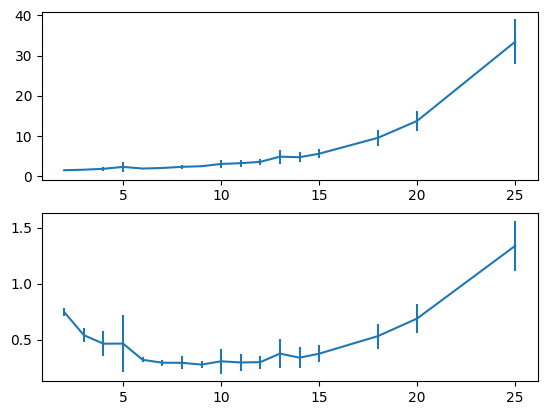

In [32]:
fig, axs = plt.subplots(2)
# plt.plot(slice_size, query_responses)

# axs[0].plot(slice_size, query_responses*1/np.array(slice_size))
# axs[0].xaxis_label("")
# axs[1].plti
#based on this analyis one could optimize "packet size"
mean_response_time = np.mean(query_responses, axis=1)
response_time_per_star = mean_response_time/slice_sizes
axs[0].errorbar(slice_sizes[1:], mean_response_time[1:], yerr=np.std(query_responses, axis=1)[1:])
axs[1].errorbar(slice_sizes[1:], response_time_per_star[1:], yerr=(np.std(query_responses, axis=1)/slice_sizes)[1:])
print(slice_sizes[response_time_per_star.argmin()], response_time_per_star.min())

In [45]:
query_nea_coordinates(coordinates[0:10], 5E-2, get_query_payload=True)

"\nSELECT pl_name FROM pscomppars WHERE CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',213.915338,19.182202, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',68.980213,16.509084, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',187.791407,-57.11318, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',101.286998,-16.715745, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',79.172437,45.997898, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',219.903981,-60.837157, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',114.825217,5.224936, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',219.910043,-60.833976, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',279.234764,38.783747, 0.05))=1 OR CONTAINS(POINT('ICRS',RA,DEC),CIRCLE('ICRS',116.328966,28.026137, 0.05))=1\n\t"

In [55]:
# check feasibility of finding an id in a list of 10^7 ids
# seems like is O(n)
bigarray = [str(i) for i in np.random.random_sample(int(1E7))]
single_element = bigarray[-1]

t1 = timeit.default_timer()
single_element in bigarray
t2 = timeit.default_timer()

print(t2-t1)


0.1419768999912776


In [64]:
# this gives an estimated total processing time for all 6000 exoplanets in NEA of
0.15 * 6000 / 60 # minutes
# starting to seem like the better option

15.0